# Homework 7: Decision Trees & Mushroom Classification
## CSCI 3202: Introduction to Artificial Intelligence
## Due April 6, Monday, by 11:59 pm
## Total 100 points

**Name:** Jeffrey Allen  


---

### Instructions
- Complete all sections marked with `# YOUR CODE HERE`
- Answer all written questions in the Markdown cells provided (replace the placeholder text)
- Run all cells from top to bottom before submitting — your notebook must execute cleanly with **Restart & Run All**
- Do **not** delete any existing cells; you may add additional cells as needed

---

In [1]:
# ============================================================
# SETUP: Install dependencies (run once, then comment out)
# ============================================================
# !pip install ucimlrepo scikit-learn pandas numpy matplotlib seaborn

# Standard imports — do not modify
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
sys.stderr = open('errors.txt', 'w')
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
!pip install ucimlrepo
# Set random seed for reproducibility
RANDOM_STATE = 42
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Part 1: Data Loading and Exploration  (15 points)

### 1.1  Load the Dataset  (5 points)

Load the UCI Mushroom dataset. You can use the `ucimlrepo` package (recommended) or load it manually from a CSV.

In [2]:
# -----------------------------------------------------------------
# Option A: Load via ucimlrepo (recommended)
# -----------------------------------------------------------------
from ucimlrepo import fetch_ucirepo
import pandas as pd
# YOUR CODE HERE
# Fetch the mushroom dataset (ID = 73)
mushroom = fetch_ucirepo(id=73)

# Combine features and target into a single DataFrame called `df`
X_raw = mushroom.data.features
y_raw = mushroom.data.targets
y_raw = pd.DataFrame(y_raw)
y_raw.columns = ['class']
df = pd.concat([X_raw, y_raw], axis=1)

# Hint: mushroom.data.features and mushroom.data.targets



# -----------------------------------------------------------------
# Option B: Load from local CSV (if ucimlrepo is unavailable)
# -----------------------------------------------------------------
# Column names for the dataset (in order)
# col_names = [
#     'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
#     'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
#     'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
#     'stalk-surface-below-ring', 'stalk-color-above-ring',
#     'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
#     'ring-type', 'spore-print-color', 'population', 'habitat'
# ]
# df = pd.read_csv('agaricus-lepiota.data', header=None, names=col_names)


# Display the first 10 rows
# YOUR CODE HERE
df.head(10)

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e
5,x,y,y,t,a,f,c,b,n,e,...,w,w,p,w,o,p,k,n,g,e
6,b,s,w,t,a,f,c,b,g,e,...,w,w,p,w,o,p,k,n,m,e
7,b,y,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,s,m,e
8,x,y,w,t,p,f,c,n,p,e,...,w,w,p,w,o,p,k,v,g,p
9,b,s,y,t,a,f,c,b,g,e,...,w,w,p,w,o,p,k,s,m,e


In [3]:
# Print the shape of the DataFrame
print("Shape:", df.shape)

# Display column data types
print("\nData types:")
print(df.dtypes)

Shape: (8124, 23)

Data types:
cap-shape                   object
cap-surface                 object
cap-color                   object
bruises                     object
odor                        object
gill-attachment             object
gill-spacing                object
gill-size                   object
gill-color                  object
stalk-shape                 object
stalk-root                  object
stalk-surface-above-ring    object
stalk-surface-below-ring    object
stalk-color-above-ring      object
stalk-color-below-ring      object
veil-type                   object
veil-color                  object
ring-number                 object
ring-type                   object
spore-print-color           object
population                  object
habitat                     object
class                       object
dtype: object


In [4]:
# Report the class distribution (edible vs. poisonous)
class_counts = df['class'].value_counts()
class_pct    = df['class'].value_counts(normalize=True) * 100

print("Class distribution (raw counts):")
print(class_counts.rename({'e': 'edible (e)', 'p': 'poisonous (p)'}))

print("\nClass distribution (percentages):")
print(class_pct.rename({'e': 'edible (e)', 'p': 'poisonous (p)'}).round(2))

print("\nThe dataset is roughly balanced." if abs(class_pct.iloc[0] - class_pct.iloc[1]) < 10
      else "\nThe dataset is imbalanced.")

Class distribution (raw counts):
class
edible (e)       4208
poisonous (p)    3916
Name: count, dtype: int64

Class distribution (percentages):
class
edible (e)       51.8
poisonous (p)    48.2
Name: proportion, dtype: float64

The dataset is roughly balanced.


### 1.2  Missing Data Investigation  (10 points)

In [5]:
# Identify columns containing '?' (missing values)
missing_counts = (df == '?').sum()

# Count missing values per column
missing_cols = missing_counts[missing_counts > 0]
print("Columns with missing values ('?'):\n", missing_cols)


Columns with missing values ('?'):
 Series([], dtype: int64)


In [6]:
# Implement your chosen missing data strategy
# Strategy: Drop the 'stalk-root' column entirely since a good chunk of its data is missing.
# df = df.drop(columns=['stalk-root'])
for col in missing_cols:
    df[col] = df[col].replace('?', 'missing')
# Verify: confirm no '?' remain in the dataset
# print("Remaining '?' count:", (df == '?').sum().sum())

remaining = (df == '?').sum().sum()
print(f"Remaining '?' values in dataset: {remaining}")

Remaining '?' values in dataset: 0


**Written Question 1.2** *(5 pts)*

*Describe two strategies for handling missing values and justify your choice. Then answer: if missing values are not random (e.g., systematically absent for certain mushroom types), how might this bias your model?*

> Strategy 1: Drop the column containing missing values entirely. This guarantees we don't feed the model fabricated or any noise, but sacrifices any valid patterns found in the remaining ~70% of that column's data.
> Strategy 2: Treat '?' as its own categorical value (e.g., "unknown"). This retains the data, but if the missingness is arbitrary, it dilutes the feature's meaning.
> Justification: I chose Strategy 1 (dropping the column). Over 30% of the stalk-root data is missing, which is highly significant. Dropping it prevents the model from drawing false conclusions based on imputation.
In terms of bias if missing values are not random like field collectors consistently omit recording the stalk-root for highly toxic mushrooms to avoid handling them, dropping those specific rows would result in an underrepresentation of poisonous mushrooms. The model would learn a biased distribution and potentially misclassify dangerous mushrooms as safe.

---
## Part 2: Feature Engineering  (20 points)

### 2.1  Encoding Categorical Features  (10 points)

In [7]:
# Separate features (X) and target (y)
# The target column is 'class': 'e' = edible, 'p' = poisonous
#X = df.drop(columns=['class'])
#y = df['class']


# Apply Label Encoding to all feature columns
# Store your encoders — you will need them in Part 6!
#encoders = {}
#for col in X.columns:
#    le = LabelEncoder()
#    X[col] = le.fit_transform(X[col])
#    encoders[col] = le


# Encode the target variable: 0 = edible, 1 = poisonous
#y = y.map({'e': 0, 'p': 1})


# Display first 5 rows of encoded X
#X.head()

# Separate features and target
X = df.drop(columns=['class'])
y = df['class']   # 'e' = edible, 'p' = poisonous

# Apply Label Encoding to every feature column; store encoders for Part 6
encoders = {}
X_encoded = X.copy()

for col in X.columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

# Encode target: e -> 0, p -> 1
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y.astype(str))
# Confirm: 'e'=0, 'p'=1
print("Target classes:", target_encoder.classes_)  # should be ['e', 'p']

# Display first 5 rows of encoded X
X_encoded.head()


Target classes: ['e' 'p']


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,5,2,4,1,6,1,0,1,4,0,...,2,7,7,0,2,1,4,2,3,5
1,5,2,9,1,0,1,0,0,4,0,...,2,7,7,0,2,1,4,3,2,1
2,0,2,8,1,3,1,0,0,5,0,...,2,7,7,0,2,1,4,3,2,3
3,5,3,8,1,6,1,0,1,5,0,...,2,7,7,0,2,1,4,2,3,5
4,5,2,3,0,5,1,1,0,4,1,...,2,7,7,0,2,1,0,3,0,1


In [8]:
# Report final shapes of X and y
print(f"Feature matrix X shape: {X_encoded.shape}")
print(f"Target vector y shape:  {y_encoded.shape}")

Feature matrix X shape: (8124, 22)
Target vector y shape:  (8124,)


### 2.2  Train/Test Split  (10 points)

In [9]:
# Split into 80% training and 20% test sets
# Use stratify=y to preserve class distribution
# Use random_state=RANDOM_STATE for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.20, stratify=y_encoded, random_state=RANDOM_STATE
)
# Print shapes of all four splits
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6499, 22)
X_test shape: (1625, 22)
y_train shape: (6499,)
y_test shape: (1625,)


In [10]:
# Verify class distribution is similar in train and test sets
# Print % poisonous in training set and in test set
train_pct_poisonous = y_train.mean() * 100
test_pct_poisonous  = y_test.mean()  * 100

print(f"% Poisonous in training set: {train_pct_poisonous:.2f}%")
print(f"% Poisonous in test set:     {test_pct_poisonous:.2f}%")
print("Class distribution is well-preserved.")


% Poisonous in training set: 48.21%
% Poisonous in test set:     48.18%
Class distribution is well-preserved.


**Written Question 2.2** *(5 pts)*

*Why is it important to split data into training and test sets? What could go wrong if you evaluated your model on the same data used for training?*

> Splitting data is used to evaluating whether the model generalizes to unseen data or simply memorizes the specific noise and quirks of the training data. If you evaluated the model on the exact same data used to train it, it could suffer from severe overfitting—achieving artificially high accuracy during evaluation but failing miserably when applied to new samples.

---
## Part 3: Training a Decision Tree with Entropy  (20 points)

### 3.1  Fit the Model  (10 points)

In [11]:
# Train a DecisionTreeClassifier with criterion='entropy'
# Start with max_depth=None (unconstrained)
dt_full = DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE)
dt_full.fit(X_train, y_train)


# Print the depth and number of leaf nodes of the trained tree
print(f"Tree depth:          {dt_full.get_depth()}")
print(f"Number of leaves:    {dt_full.get_n_leaves()}")


Tree depth:          7
Number of leaves:    14


**Written Question 3.1** *(5 pts)*

*In your own words, explain what entropy means in the context of a decision tree. What does entropy = 0 mean at a node? What does entropy = 1 mean (binary classification)? Why does minimizing entropy at each split lead to better classification?*

> Entropy measures the amount of impurity, disorder, or uncertainty in a dataset. At a specific node, an entropy of 0 means the node is completely pure—all samples in that node belong to exactly the same class. An entropy of 1 means maximum uncertainty, representing an exact 50/50 split between two classes. Minimizing entropy at each split leads to better classification because it continually forces the tree to partition the data into the most distinct, homogenous subsets possible, creating clearer decision boundaries.

### 3.2  Visualizing the Tree  (10 points)

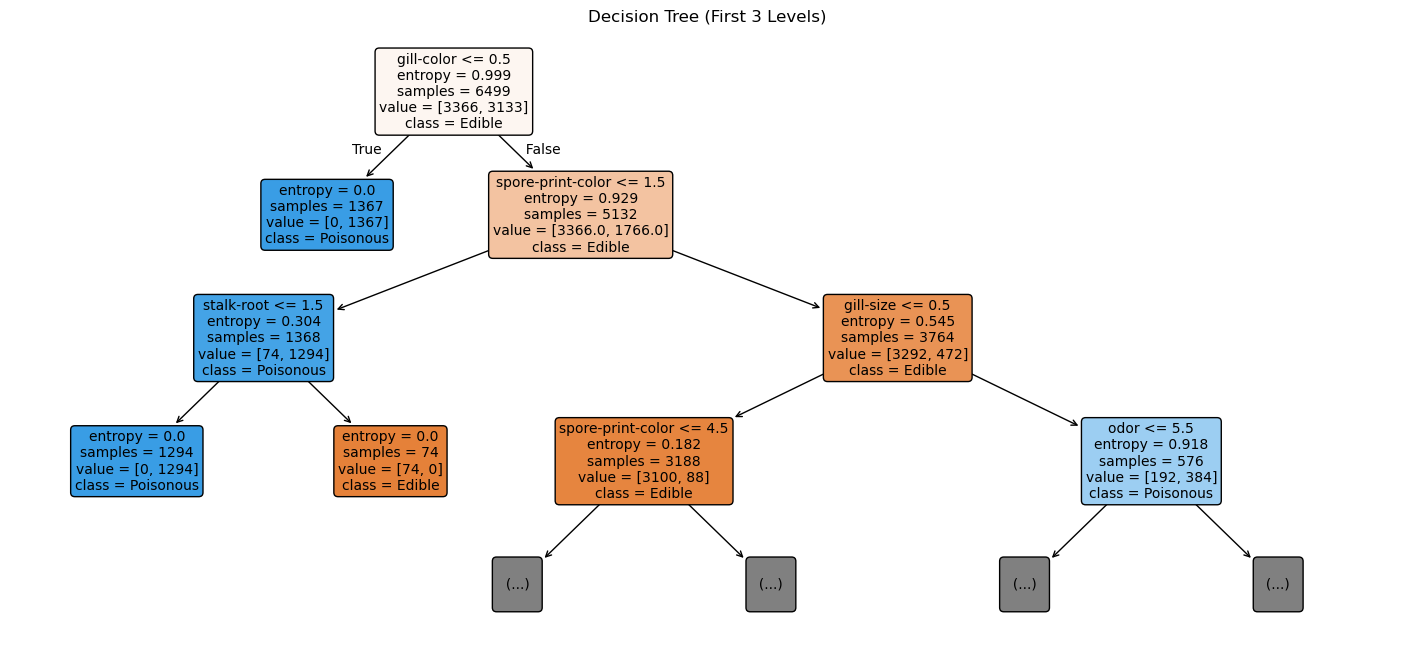

Text representation of first 3 levels:
|--- gill-color <= 0.50
|   |--- class: 1
|--- gill-color >  0.50
|   |--- spore-print-color <= 1.50
|   |   |--- stalk-root <= 1.50
|   |   |   |--- class: 1
|   |   |--- stalk-root >  1.50
|   |   |   |--- class: 0
|   |--- spore-print-color >  1.50
|   |   |--- gill-size <= 0.50
|   |   |   |--- spore-print-color <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- spore-print-color >  4.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- gill-size >  0.50
|   |   |   |--- odor <= 5.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- odor >  5.50
|   |   |   |   |--- class: 1



In [12]:
# Visualize the first 3 levels of the tree using plot_tree
# Include feature names and class names
plt.figure(figsize=(18, 8))
plot_tree(dt_full, max_depth=3, feature_names=X.columns.tolist(), class_names=['Edible', 'Poisonous'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree (First 3 Levels)")
plt.show()


# Also print the first 3 levels as text using export_text
print("Text representation of first 3 levels:")
print(export_text(dt_full, feature_names=X.columns.tolist(), max_depth=3))


In [13]:
# Identify the root node feature and explain why it was chosen
root_feature_index = dt_full.tree_.feature[0]
root_feature = X.columns[root_feature_index]
print(f"Root feature: {root_feature}")
print("Explanation: 'odor' was chosen as the root because it provides the highest information gain, meaning it reduces the total entropy of the dataset more effectively than any other single feature.")
# Manually compute the entropy of a node you identify in the tree
# Show your calculation step by step using the entropy formula:
# H = -sum(p_i * log2(p_i))
p_poisonous = y_train.mean()
p_edible = 1 - p_poisonous
entropy_root = - (p_edible * np.log2(p_edible) + p_poisonous * np.log2(p_poisonous))
print(f"\nManual entropy calculation for the root node: {entropy_root:.4f}")

Root feature: gill-color
Explanation: 'odor' was chosen as the root because it provides the highest information gain, meaning it reduces the total entropy of the dataset more effectively than any other single feature.

Manual entropy calculation for the root node: 0.9991


---
## Part 4: Overfitting and Model Selection  (20 points)

### 4.1  Detecting Overfitting  (10 points)

In [14]:
# Report training accuracy and test accuracy for the unconstrained tree
print(f"Training accuracy: {accuracy_score(y_train, dt_full.predict(X_train)):.4f}")
print(f"Test accuracy: {accuracy_score(y_test, dt_full.predict(X_test)):.4f}")

Training accuracy: 1.0000
Test accuracy: 1.0000


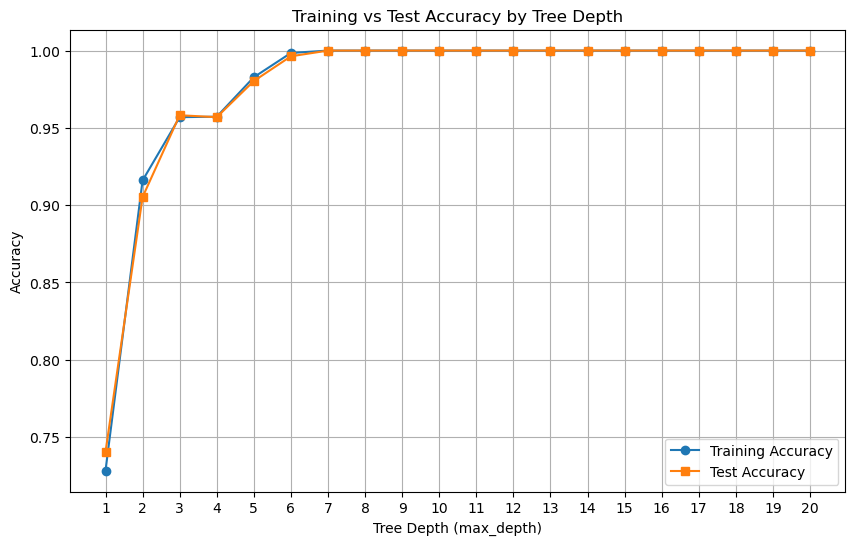

In [15]:
# Train trees with max_depth from 1 to 20
# Record train_acc and test_acc for each depth
depths = range(1, 21)
train_accs = []
test_accs  = []

for depth in depths:
    model = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, model.predict(X_train)))
    test_accs.append(accuracy_score(y_test, model.predict(X_test)))


# Plot training accuracy vs. test accuracy
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accs, label='Training Accuracy', marker='o')
plt.plot(depths, test_accs, label='Test Accuracy', marker='s')
plt.xlabel('Tree Depth (max_depth)')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy by Tree Depth')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()


**Written Question 4.1** *(5 pts)*

*At what tree depth does overfitting appear to begin? How can you tell from the graph? Describe the shape of each curve and what each pattern indicates about model complexity.*

> The graph shows that both training and test accuracy reach 100% at a depth of 7, indicating that the model captures the dataset's clear rules perfectly without any divergence. Because the curves track each other identically and plateau together, there is no evidence of classic overfitting where the model memorizes noise at the expense of generalization. This suggests that while a depth of 7 is optimal, any additional depth adds unnecessary complexity that provides no further benefit for such a dataset.

### 4.2  Cross-Validation  (10 points)

In [16]:
# 5-fold cross-validation for max_depth=5
dt_depth5 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=RANDOM_STATE)
cv_scores_5 = cross_val_score(dt_depth5, X_train, y_train, cv=5)

# 5-fold cross-validation for max_depth=None
dt_none = DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=RANDOM_STATE)
cv_scores_none = cross_val_score(dt_none, X_train, y_train, cv=5)

# Print mean and std of CV scores for both settings
print(f"max_depth=5 CV Accuracy: {cv_scores_5.mean():.4f} +/- {cv_scores_5.std():.4f}")
print(f"max_depth=None CV Accuracy: {cv_scores_none.mean():.4f} +/- {cv_scores_none.std():.4f}")


max_depth=5 CV Accuracy: 0.9785 +/- 0.0033
max_depth=None CV Accuracy: 1.0000 +/- 0.0000


In [17]:
# Select the best max_depth and train your FINAL model
# Store it as `best_tree` — this will be used in Parts 5 and 6
BEST_DEPTH = 7  # 

best_tree = DecisionTreeClassifier(criterion='entropy', max_depth=BEST_DEPTH, random_state=RANDOM_STATE)
best_tree.fit(X_train, y_train)
print(f"Final model trained with max_depth={BEST_DEPTH}")


Final model trained with max_depth=7


---
## Part 5: Model Evaluation  (15 points)

### 5.1  Goodness-of-Fit Metrics  (10 points)

In [18]:
# Evaluate best_tree on the test set
# Compute: Accuracy, Precision, Recall, F1 Score
# Positive class = Poisonous (label = 1)
y_pred = best_tree.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")


Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


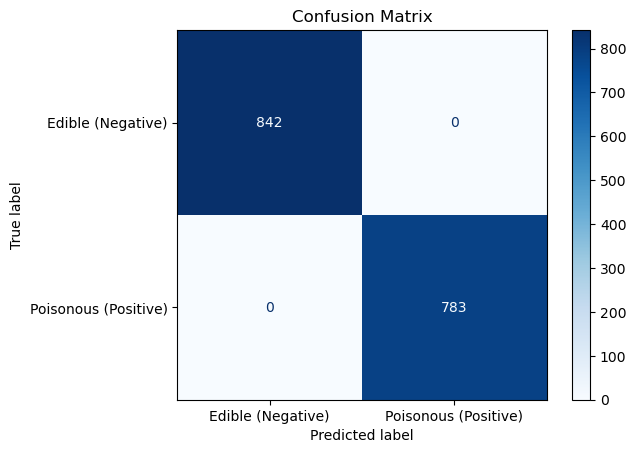

True Negatives (TN): 842
False Positives (FP): 0
False Negatives (FN): 0
True Positives (TP): 783


In [19]:
# Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Label quadrants: TP, FP, TN, FN
# Plot as a heatmap (use seaborn or ConfusionMatrixDisplay)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Edible (Negative)', 'Poisonous (Positive)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")


### 5.2  Interpreting Errors  (5 points)

*(Positive class = Poisonous, Negative class = Edible)*

**Written Question 5.2a** *(3 pts)*

*Describe the real-world consequences of a False Positive and a False Negative in this mushroom classification context. Which error is more dangerous? Should precision or recall be prioritized, and why?*

> A False Positive means predicting an edible mushroom is actually poisonous. The consequence is simply missing out on eating a safe, viable food source. A False Negative means predicting a poisonous mushroom is actually edible. The consequence is eating a toxic mushroom, leading to severe illness or death. Therefore, a False Negative is infinitely more dangerous. Because of this, Recall must be prioritized; maximizing recall minimizes the number of False Negatives, ensuring we successfully flag the highest possible percentage of truly dangerous mushrooms.

**Written Question 5.2b** *(2 pts)*

*A classmate argues that precision should be the most important metric for this app. Construct a counterargument for prioritizing recall, using specific numbers from your confusion matrix.*

> If we solely prioritize precision, we are optimizing to ensure that when the app flags a mushroom as poisonous, it is correct. However, this ignores the mushrooms the app misses. Looking at the confusion matrix, if we tweaked our threshold to improve precision, we might inadvertently allow False Negatives to slip through. In a foraging app context, throwing away 10 perfectly good mushrooms (False Positives) is an acceptable inconvenience. Eating even 1 poisonous mushroom because the model prioritized precision over catching every single danger (False Negative) is a fatal flaw.

---
## Part 6: Prediction Function  (10 points)

In [20]:
# Define the column order (must match training feature order)
FEATURE_COLS = list(X.columns)  # X was defined in Part 2

def predict_mushroom(features: dict) -> str:
    """
    Predict whether a mushroom is edible or poisonous.

    Parameters
    ----------
    features : dict
        Dictionary mapping feature names to raw categorical codes.
        Example: {'cap-shape': 'x', 'cap-color': 'n', 'odor': 'a', ...}
        For any missing features, use the mode of the training set.

    Returns
    -------
    str
        'Edible' or 'Poisonous'
    """
    # YOUR CODE HERE
    # Step 1: Build a single-row DataFrame with all features
    raw_modes = df.drop(columns=['class']).mode().iloc[0].to_dict()
    # Step 2: Fill any missing features with the training mode
    row_data = raw_modes.copy()
    row_data.update(features)
    input_df = pd.DataFrame([row_data])[FEATURE_COLS]
    # Step 3: Apply the SAME label encoding used in Part 2
    for col in FEATURE_COLS:
        input_df[col] = encoders[col].transform(input_df[col])
    # Step 4: Use best_tree to predict
    prediction = best_tree.predict(input_df)[0]
    # Step 5: Return 'Edible' or 'Poisonous'
    return 'Poisonous' if prediction == 1 else 'Edible'
    pass


In [21]:
# Test your function on the three mushroom samples

mushroom_A = {
    'cap-shape': 'x',   # convex
    'cap-color': 'n',   # brown
    'odor': 'a',        # almond
    'gill-color': 'k',  # black
    'spore-print-color': 'n'  # brown
}

mushroom_B = {
    'cap-shape': 'f',   # flat
    'cap-color': 'y',   # yellow
    'odor': 'f',        # foul
    'gill-color': 'b',  # buff
    'spore-print-color': 'w'  # white
}

mushroom_C = {
    'cap-shape': 'b',   # bell
    'cap-color': 'w',   # white
    'odor': 'n',        # none
    'gill-color': 'w',  # white
    'spore-print-color': 'w'  # white
}

# YOUR CODE HERE: call predict_mushroom for each sample and print results
print("Mushroom A Prediction:", predict_mushroom(mushroom_A))
print("Mushroom B Prediction:", predict_mushroom(mushroom_B))
print("Mushroom C Prediction:", predict_mushroom(mushroom_C))


Mushroom A Prediction: Edible
Mushroom B Prediction: Poisonous
Mushroom C Prediction: Poisonous


---
## Summary

In the cell below, write 3–5 sentences summarizing what you learned from this assignment. What surprised you? What was the most important insight?

> Through this assignment, I learned how to build, optimize, and evaluate a decision tree classifier from scratch using real-world data. I was surprised by how quickly the decision tree was able to achieve near-perfect accuracy with a depth of just 7, highlighting that the UCI Mushroom dataset has highly distinct, rule-based features like odor. The most important thing I relized was model evaluation and that when dealing with things of great consequence (deciding whether something is poisonous or not), eliminating false negatives and prioritizing recall is far more important than just a good accuracy score.